# Tugas Kuliah PCD 03
Nama    : Syafiq Syadidul Azmi <br>
NIM     : G6401231075 <br>
Paralel : 3

In [291]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [292]:
hawar_daun = cv2.imread('hawardaun.png')
chlorosis = cv2.imread('begomovirus.jpg')

In [293]:
def rgb_to_hsv(img):

    img = img.astype(np.float32) / 255.0
    B = img[:,:,0]
    G = img[:,:,1]
    R = img[:,:,2]

    Cmax = np.maximum(np.maximum(R, G), B)
    Cmin = np.minimum(np.minimum(R, G), B)
    delta = Cmax - Cmin

    H = np.zeros_like(Cmax)
    S = np.zeros_like(Cmax)
    V = Cmax

    # Hue
    mask = delta != 0

    idx = (Cmax == R) & mask
    H[idx] = (60 * ((G[idx] - B[idx]) / delta[idx]) % 360)

    idx = (Cmax == G) & mask
    H[idx] = (60 * ((B[idx] - R[idx]) / delta[idx]) + 120)

    idx = (Cmax == B) & mask
    H[idx] = (60 * ((R[idx] - G[idx]) / delta[idx]) + 240)

    # Saturation
    S[Cmax != 0] = delta[Cmax != 0] / Cmax[Cmax != 0]

    H = (H / 2).astype(np.uint8)     
    S = (S * 255).astype(np.uint8)
    V = (V * 255).astype(np.uint8)

    hsv = np.stack([H,S,V], axis=2)
    return hsv

In [294]:
def rgb_to_lab(img):

    img = img.astype(np.float32) / 255.0
    B = img[:,:,0]
    G = img[:,:,1]
    R = img[:,:,2]

    # RGB → XYZ
    X = 0.4124*R + 0.3576*G + 0.1805*B
    Y = 0.2126*R + 0.7152*G + 0.0722*B
    Z = 0.0193*R + 0.1192*G + 0.9505*B

    # Fungsi f(t)
    def f(t):
        mask = t > 0.008856
        t[mask] = t[mask] ** (1/3)
        t[~mask] = (7.787 * t[~mask]) + (16/116)
        return t

    fx = f(X)
    fy = f(Y)
    fz = f(Z)

    L = (116 * fy) - 16
    a = 500 * (fx - fy)
    b = 200 * (fy - fz)

    # Scaling ke 0-255
    L = (L * 255 / 100)
    a = a + 128
    b = b + 128

    lab = np.stack([L, a, b], axis=2)
    lab = np.clip(lab, 0, 255).astype(np.uint8)

    return lab

## Chlorosis

In [295]:
chlorosis_lab = rgb_to_lab(chlorosis)
L_channel, a_channel, b_channel = cv2.split(chlorosis_lab)

chlorosis_hsv = rgb_to_hsv(chlorosis)
H_channel, S_channel, V_channel = cv2.split(chlorosis_hsv)

lab histogram

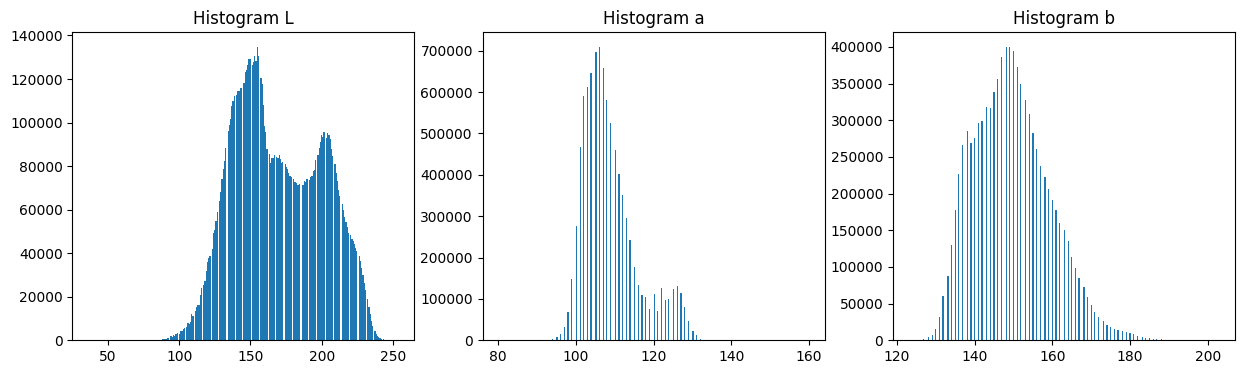

In [296]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(L_channel.ravel(), bins=256)
plt.title("Histogram L")

plt.subplot(1,3,2)
plt.hist(a_channel.ravel(), bins=256)
plt.title("Histogram a")

plt.subplot(1,3,3)
plt.hist(b_channel.ravel(), bins=256)
plt.title("Histogram b")

plt.show()

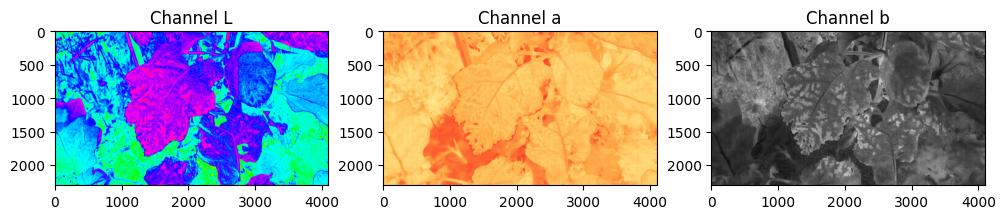

In [297]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.imshow(L_channel, cmap='hsv')  # hsv colormap biar keliatan spektrum warnanya
plt.title("Channel L")

plt.subplot(1,3,2)
plt.imshow(a_channel, cmap='YlOrRd')  # kuning ke merah, makin jenuh makin merah
plt.title("Channel a")

plt.subplot(1,3,3)
plt.imshow(b_channel, cmap='gray')  # V itu kecerahan, gray udah cukup
plt.title("Channel b")

plt.show()

hsv histogram

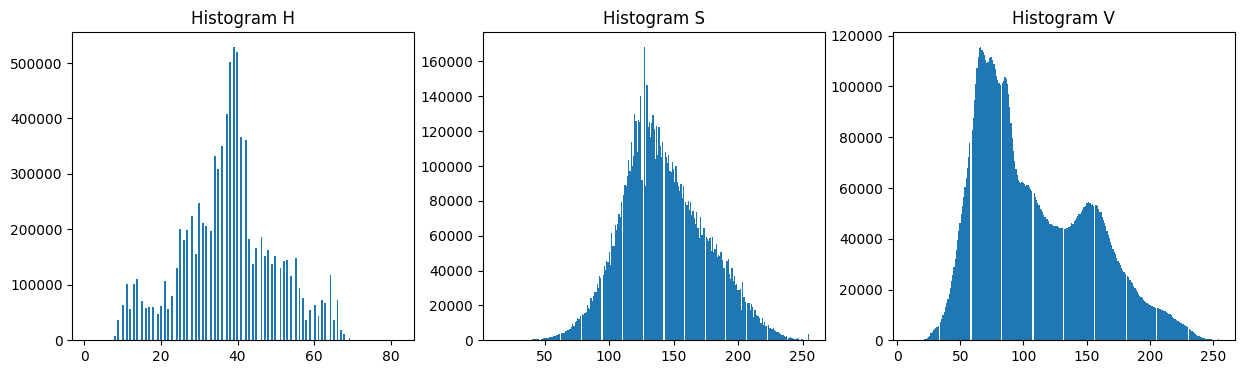

In [298]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(H_channel.ravel(), bins=180)
plt.title("Histogram H")

plt.subplot(1,3,2)
plt.hist(S_channel.ravel(), bins=256)
plt.title("Histogram S")

plt.subplot(1,3,3)
plt.hist(V_channel.ravel(), bins=256)
plt.title("Histogram V")

plt.show()

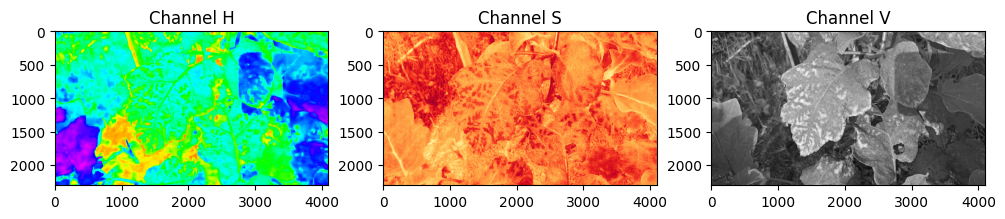

In [299]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.imshow(H_channel, cmap='hsv')  # hsv colormap biar keliatan spektrum warnanya
plt.title("Channel H")

plt.subplot(1,3,2)
plt.imshow(S_channel, cmap='YlOrRd')  # kuning ke merah, makin jenuh makin merah
plt.title("Channel S")

plt.subplot(1,3,3)
plt.imshow(V_channel, cmap='gray')  # V itu kecerahan, gray udah cukup
plt.title("Channel V")

plt.show()

Thresholding

In [300]:
mask_lab = (L_channel >= 180) & (b_channel >= 160)

mask_lab = mask_lab.astype(np.uint8) * 255

In [301]:
# tambahin V >= 80 biar background gelap kefilter
mask_hsv = (H_channel >= 15) & (H_channel <= 30) & (S_channel >= 50) & (V_channel >= 80)

mask_hsv = mask_hsv.astype(np.uint8) * 255

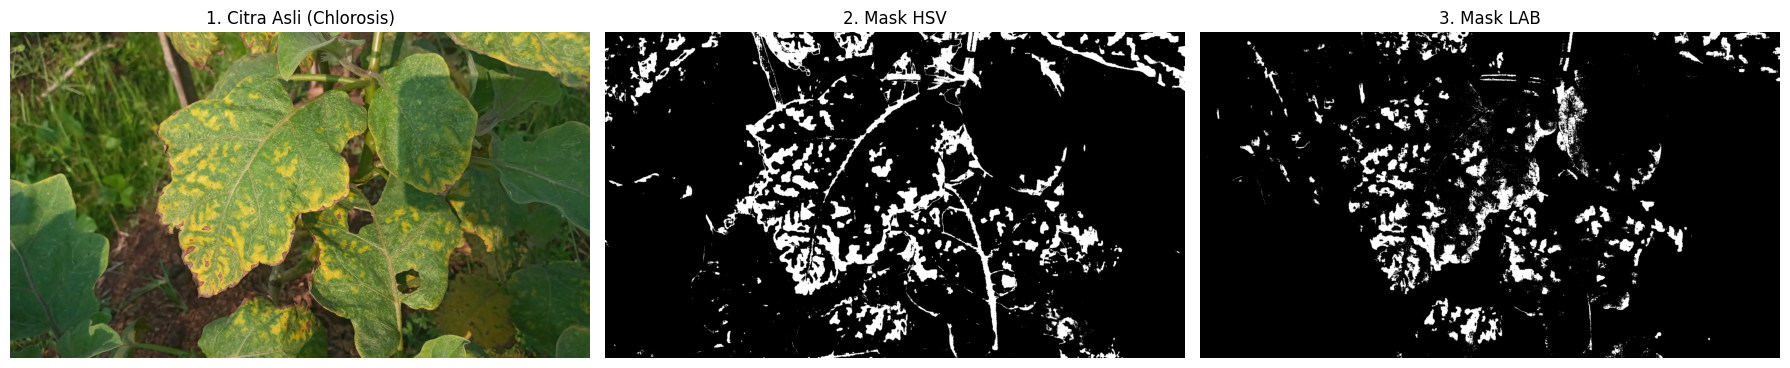

In [302]:
import matplotlib.pyplot as plt
import cv2

# Membuat layout 1 baris, 3 kolom
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. Citra Asli
# OpenCV bacanya BGR, jadi harus di-convert ke RGB biar warnanya bener di plt
ax[0].imshow(cv2.cvtColor(chlorosis, cv2.COLOR_BGR2RGB))
ax[0].set_title("1. Citra Asli (Chlorosis)")
ax[0].axis("off")

# 2. Mask HSV
ax[1].imshow(mask_hsv, cmap='gray')
ax[1].set_title("2. Mask HSV")
ax[1].axis("off")

# 3. Mask LAB
ax[2].imshow(mask_lab, cmap='gray')
ax[2].set_title("3. Mask LAB")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [303]:
print("H min:", H_channel.min(), "H max:", H_channel.max())
print("S min:", S_channel.min(), "S max:", S_channel.max())

H min: 1 H max: 82
S min: 14 S max: 255


## Persentase Area Terinfeksi (Chlorosis)

In [304]:
# Hitung persentase piksel putih (area terinfeksi) dari total piksel
total_piksel = mask_lab.size
area_hsv = np.sum(mask_hsv == 255)
area_lab = np.sum(mask_lab == 255)

persen_hsv = (area_hsv / total_piksel) * 100
persen_lab = (area_lab / total_piksel) * 100

print(f'Persentase area chlorosis (HSV): {persen_hsv:.2f}%')
print(f'Persentase area chlorosis (LAB): {persen_lab:.2f}%')

Persentase area chlorosis (HSV): 12.62%
Persentase area chlorosis (LAB): 7.40%


## Uji Stabilitas terhadap Perubahan Brightness (Chlorosis)

Cara kerjanya: kita bikin versi lebih gelap dan lebih terang dari gambar asli, lalu hitung ulang persentase area. Kalau persentasenya nggak banyak berubah, berarti metode itu robust.

In [305]:
# Buat 3 versi: gelap (0.5x), asli (1x), terang (1.5x)
versions = {
    'Gelap (0.5x)' : np.clip(chlorosis * 0.5, 0, 255).astype(np.uint8),
    'Asli (1x)'    : chlorosis,
    'Terang (1.5x)': np.clip(chlorosis * 1.5, 0, 255).astype(np.uint8),
}

print(f'{'Versi':<15} {'HSV (%)':>10} {'LAB (%)':>10}')
print('-' * 38)

for nama, img in versions.items():
    # Konversi tiap versi
    hsv = rgb_to_hsv(img)
    lab = rgb_to_lab(img)
    H, S, V = cv2.split(hsv)
    L, a, b = cv2.split(lab)

    # Pakai threshold yang sama
    m_hsv = (H >= 15) & (H <= 30) & (S >= 50) & (V >= 80)
    m_lab = (L >= 180) & (b >= 160)

    p_hsv = np.sum(m_hsv) / m_hsv.size * 100
    p_lab = np.sum(m_lab) / m_lab.size * 100

    print(f'{nama:<15} {p_hsv:>10.2f} {p_lab:>10.2f}')

Versi              HSV (%)    LAB (%)
--------------------------------------
Gelap (0.5x)          6.97       0.00
Asli (1x)            12.62       7.40
Terang (1.5x)        19.54      18.46


---
## Studi Kasus A – Hawar Daun

In [306]:
# Konversi hawar daun ke HSV dan LAB
hawar_hsv = rgb_to_hsv(hawar_daun)
hawar_lab = rgb_to_lab(hawar_daun)

H_h, S_h, V_h = cv2.split(hawar_hsv)
L_h, a_h, b_h = cv2.split(hawar_lab)

### Histogram Hawar Daun

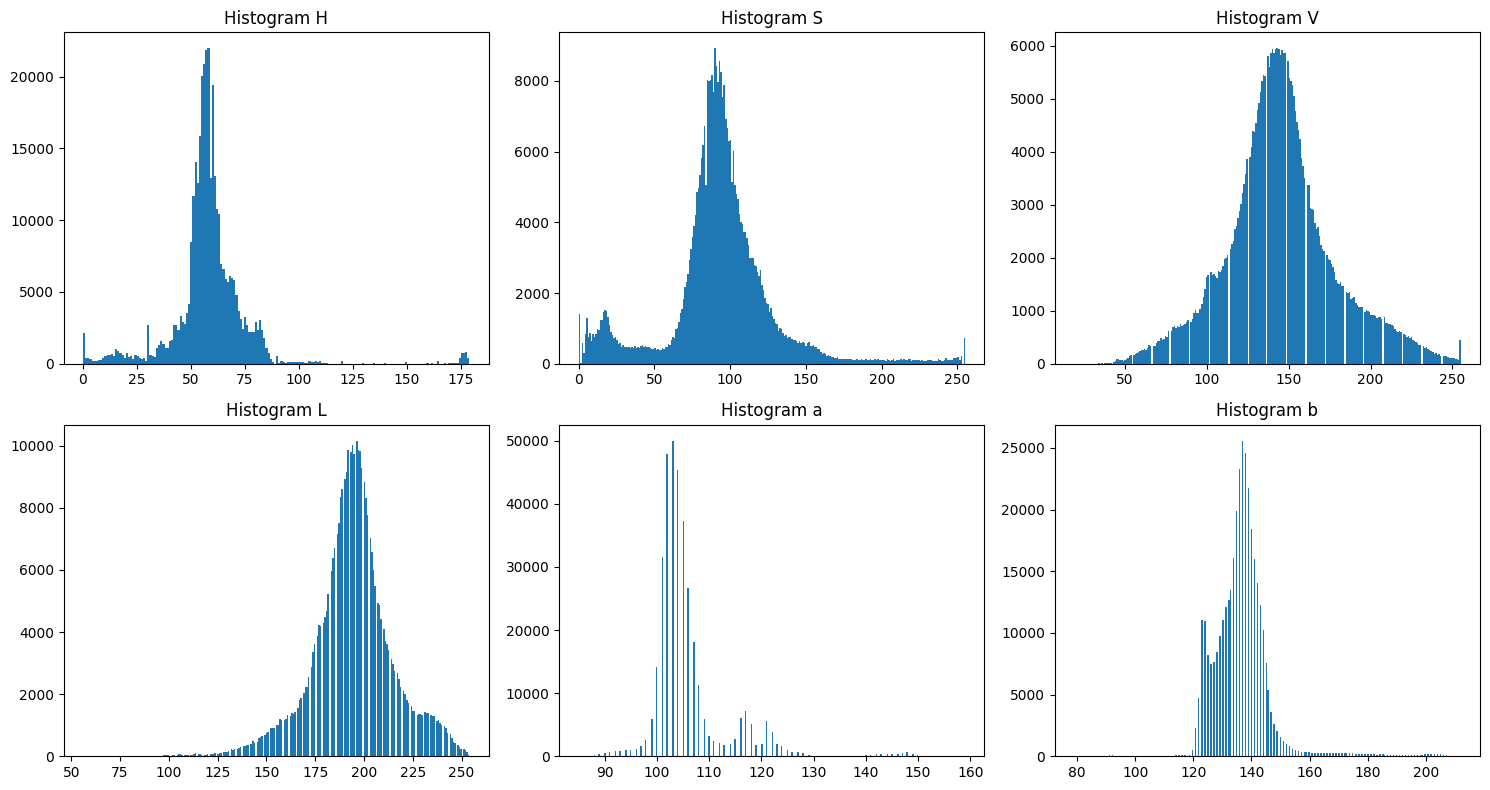

In [307]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Baris 1: HSV
axes[0,0].hist(H_h.ravel(), bins=180); axes[0,0].set_title('Histogram H')
axes[0,1].hist(S_h.ravel(), bins=256); axes[0,1].set_title('Histogram S')
axes[0,2].hist(V_h.ravel(), bins=256); axes[0,2].set_title('Histogram V')

# Baris 2: LAB
axes[1,0].hist(L_h.ravel(), bins=256); axes[1,0].set_title('Histogram L')
axes[1,1].hist(a_h.ravel(), bins=256); axes[1,1].set_title('Histogram a')
axes[1,2].hist(b_h.ravel(), bins=256); axes[1,2].set_title('Histogram b')

plt.tight_layout()
plt.show()

### Visualisasi Channel Hawar Daun

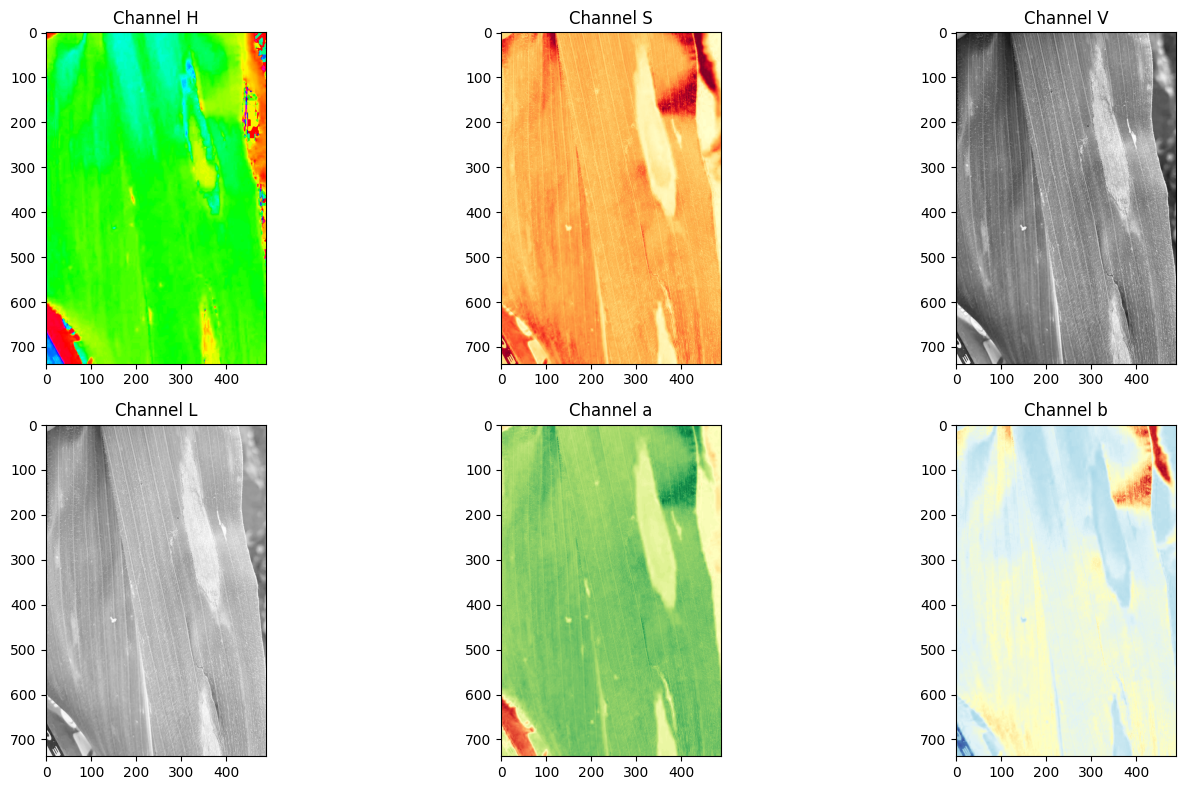

In [308]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Baris 1: HSV
axes[0,0].imshow(H_h, cmap='hsv');    axes[0,0].set_title('Channel H')
axes[0,1].imshow(S_h, cmap='YlOrRd'); axes[0,1].set_title('Channel S')
axes[0,2].imshow(V_h, cmap='gray');   axes[0,2].set_title('Channel V')

# Baris 2: LAB
axes[1,0].imshow(L_h, cmap='gray');      axes[1,0].set_title('Channel L')
axes[1,1].imshow(a_h, cmap='RdYlGn_r'); axes[1,1].set_title('Channel a')
axes[1,2].imshow(b_h, cmap='RdYlBu_r'); axes[1,2].set_title('Channel b')

plt.tight_layout()
plt.show()

### Thresholding Hawar Daun

Area nekrotik (coklat/abu) → V rendah (gelap), Hue di rentang oranye-coklat (0–15), Saturation rendah-sedang.

In [309]:
# S diturunin dikit, V dilonggarin bawahnya
mask_hawar_hsv = (S_h <= 50) & (V_h >= 140) & (V_h <= 245)
mask_hawar_hsv = mask_hawar_hsv.astype(np.uint8) * 255

# LAB Hawar (Standar Baru)
# L >= 180 tetap oke buat ambil area terang/pucat
# b_h kita longgarkan dari 130 ke 150
# a_h >= 110 buat mastiin yang ijo banget (daun sehat) gak ikut masuk
mask_hawar_lab = (L_h >= 160) & (L_h <= 245) & \
                 (b_h >= 120) & (b_h <= 150) & \
                 (a_h >= 115)
mask_hawar_lab = mask_hawar_lab.astype(np.uint8) * 255

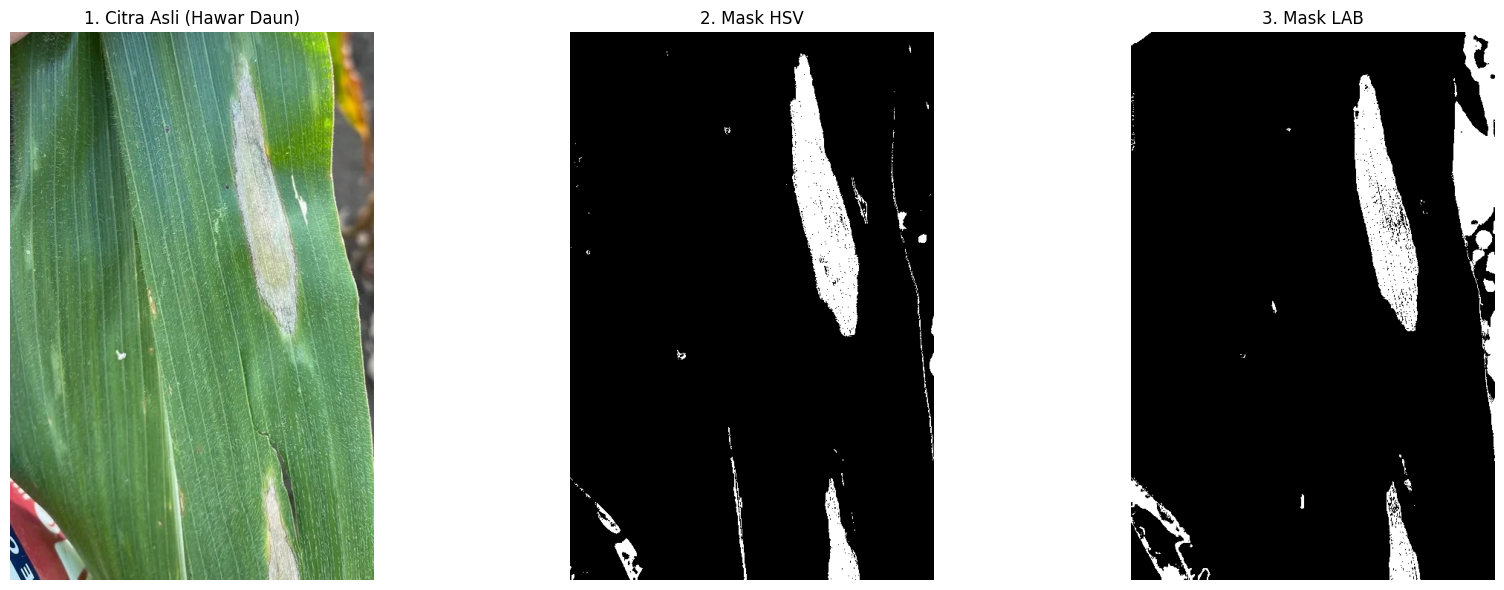

In [310]:
# Tampilkan hasil segmentasi hawar daun
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(cv2.cvtColor(hawar_daun, cv2.COLOR_BGR2RGB))
ax[0].set_title('1. Citra Asli (Hawar Daun)'); ax[0].axis('off')

ax[1].imshow(mask_hawar_hsv, cmap='gray')
ax[1].set_title('2. Mask HSV'); ax[1].axis('off')

ax[2].imshow(mask_hawar_lab, cmap='gray')
ax[2].set_title('3. Mask LAB'); ax[2].axis('off')

plt.tight_layout()
plt.show()

### Persentase Area Terinfeksi (Hawar Daun)

In [311]:
total = mask_hawar_lab.size
p_hsv = np.sum(mask_hawar_hsv == 255) / total * 100
p_lab = np.sum(mask_hawar_lab == 255) / total * 100

print(f'Persentase area hawar daun (HSV): {p_hsv:.2f}%')
print(f'Persentase area hawar daun (LAB): {p_lab:.2f}%')

Persentase area hawar daun (HSV): 6.41%
Persentase area hawar daun (LAB): 9.39%


### Uji Stabilitas Brightness (Hawar Daun)

In [312]:
versions = {
    'Gelap (0.5x)' : np.clip(hawar_daun * 0.5, 0, 255).astype(np.uint8),
    'Asli (1x)'    : hawar_daun,
    'Terang (1.5x)': np.clip(hawar_daun * 1.5, 0, 255).astype(np.uint8),
}

print(f'{'Versi':<15} {'HSV (%)':>10} {'LAB (%)':>10}')
print('-' * 38)

for nama, img in versions.items():
    hsv = rgb_to_hsv(img)
    lab = rgb_to_lab(img)
    H, S, V = cv2.split(hsv)
    L, a, b = cv2.split(lab)

    m_hsv = (H <= 15) & (S >= 30) & (V <= 160)
    m_lab = (L <= 150) & (a >= 110) & (a <= 140)

    p_hsv = np.sum(m_hsv) / m_hsv.size * 100
    p_lab = np.sum(m_lab) / m_lab.size * 100

    print(f'{nama:<15} {p_hsv:>10.2f} {p_lab:>10.2f}')

Versi              HSV (%)    LAB (%)
--------------------------------------
Gelap (0.5x)          1.76      20.15
Asli (1x)             1.46       0.98
Terang (1.5x)         0.47       0.26
